# Chitin
Throughout all of my analyses, things seem to come back to chitin - whether it's a DEG, hub gene, or enriched GO term. I'm interested to dig a bit more on this and explore differences in VST expression of genes related to chitin, along with the correlation with growth.

## 0. load libraries

In [52]:
library(tidyverse) # for dplyr, stringr, ggplot
library(KEGGREST) # for KEGG pathways
library(multcompView) # for stat labels on ggplot
library(GO.db)
library(AnnotationDbi)
library(rtracklayer)
library(ggrepel)
library(broom)
library(RColorBrewer)

## 1. load CSVs

### vst

In [4]:
# phase 1 oysters
p1.vst <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/new_refGenome/deseq_res/prefilter_deseq/p1_vst.csv')%>%
  pivot_longer(cols = -X,
             names_to = 'Sample',
             values_to = 'vst') %>%
rename_with(~ "Gene", 1)

head(p1.vst)

Gene,Sample,vst
<chr>,<chr>,<dbl>
LOC144621260,B1_Nu_O03,11.21797
LOC144621260,B2_Nu_O12,11.93477
LOC144621260,B4_Nu_O32,11.22476
LOC144621260,B5_Nu_O36,11.38600
LOC144621260,B6_Nu_O47,11.49149
LOC144621260,C1_Nu_W01,11.33041


In [5]:
# phase 2 oysters
p2.vst <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/deseq_res/prefilter_deseq/vst_filtered.csv')%>%
  pivot_longer(cols = -X,
             names_to = 'Sample',
             values_to = 'vst') %>%
rename_with(~ "Gene", 1)

head(p2.vst)

Gene,Sample,vst
<chr>,<chr>,<dbl>
LOC144621260,B1_B1_O01,11.62347
LOC144621260,B1_W5_O50,11.42347
LOC144621260,B2_B5_O51,11.40884
LOC144621260,B2_C4_O40,11.27515
LOC144621260,B3_B4_O41,11.00057
LOC144621260,B3_C3_O30,10.98404


In [6]:
vst.all <- rbind(p1.vst, p2.vst)
head(vst.all)

Gene,Sample,vst
<chr>,<chr>,<dbl>
LOC144621260,B1_Nu_O03,11.21797
LOC144621260,B2_Nu_O12,11.93477
LOC144621260,B4_Nu_O32,11.22476
LOC144621260,B5_Nu_O36,11.38600
LOC144621260,B6_Nu_O47,11.49149
LOC144621260,C1_Nu_W01,11.33041


### meta data

In [7]:
meta <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/metaData/sample_metaData.csv') %>%
mutate(complete_trtmt  = paste0(Phase1_treatment, '_', Phase2_treatment)) %>%
dplyr::select(Sample, Phase1_temp, Phase1_DO, Phase1_treatment, Phase2_temp, Phase2_DO, Phase2_treatment, complete_trtmt)

head(meta)

,Sample,Phase1_temp,Phase1_DO,Phase1_treatment,Phase2_temp,Phase2_DO,Phase2_treatment,complete_trtmt
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,B1_B1_O01,warm,hypoxic,both,warm,hypoxic,both,both_both
2,B1_Nu_O03,warm,hypoxic,both,NA,NA,NA,both_NA
3,B1_W5_O50,warm,hypoxic,both,warm,normoxic,warm,both_warm
4,B2_B5_O51,warm,hypoxic,both,warm,hypoxic,both,both_both
5,B2_C4_O40,warm,hypoxic,both,ambient,normoxic,control,both_control
6,B2_Nu_O12,warm,hypoxic,both,NA,NA,NA,both_NA


#### growth data

In [8]:
p2_growth <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/metaData/growth_phase2.1_weights.csv')

# add leading zeros to single digit tag num
p2_growth$Tag_num <- sprintf("%02d", p2_growth$Tag_num)

# make sample names same as my convention
p1_str <- str_sub(p2_growth$Phase_1_treat, 1, 1)
p2_str <- str_sub(p2_growth$Phase_2_treat, 1, 1)
p2_growth$Sample <- paste0(p1_str, p2_growth$Phase_1_rep, '_', p2_str, p2_growth$Phase_2_rep, '_', p2_growth$Tag_color, p2_growth$Tag_num)

# select the columns of interest
p2_growth <- p2_growth %>%
dplyr::select(Sample, Actual_shell_growth_mg, Actual_tissue_growth_mg, Ratio_tissue_shell_mg)

head(p2_growth)

,Sample,Actual_shell_growth_mg,Actual_tissue_growth_mg,Ratio_tissue_shell_mg
,<chr>,<dbl>,<dbl>,<chr>
1,B1_B1_O01,210.27552,120.72448,0.574125224
2,B1_B1_O02,269.01966,72.58034,0.269795672
3,B1_B2_O13,418.96764,124.23236,0.29652018
4,B1_B2_O14,285.32868,148.97132,0.522104262
5,B1_B3_O25,75.84486,20.65514,0.272334078
6,B1_B3_O26,182.09100,44.30900,0.243334377


In [9]:
p1_growth <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/metaData/growth_phase1_weights.csv')

# add leading zeros to single digit tag num
p1_growth$Tag_num <- sprintf("%02d", p1_growth$Tag_num)

# make sample names same as my convention
p1_str <- str_sub(p1_growth$Phase_1_treat, 1, 1)
p1_growth$Sample <- paste0(p1_str, p1_growth$Phase_1_rep, '_Nu_', p1_growth$Tag_color, p1_growth$Tag_num)

# select the columns of interest
p1_growth <- p1_growth %>%
dplyr::select(Sample, Actual_shell_growth_mg, Actual_tissue_growth_mg, Ratio_tissue_shell_mg)

head(p1_growth)

,Sample,Actual_shell_growth_mg,Actual_tissue_growth_mg,Ratio_tissue_shell_mg
,<chr>,<dbl>,<dbl>,<chr>
1,B1_Nu_O01,42.27678,21.92322,0.518564091
2,B1_Nu_O02,63.65268,42.34732,0.665287306
3,B1_Nu_O03,77.58660,27.91340,0.359770888
4,B1_Nu_O04,157.38996,148.21004,0.941674043
5,B1_Nu_O05,-19.47582,-40.02418,2.055070339
6,B1_Nu_O06,181.29930,117.50070,0.64810344


#### merge meta and growth data

In [10]:
growth <- rbind(p1_growth, p2_growth)
metaData <- merge(meta, growth, by = 'Sample')
head(metaData)

,Sample,Phase1_temp,Phase1_DO,Phase1_treatment,Phase2_temp,Phase2_DO,Phase2_treatment,complete_trtmt,Actual_shell_growth_mg,Actual_tissue_growth_mg,Ratio_tissue_shell_mg
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>
1,B1_B1_O01,warm,hypoxic,both,warm,hypoxic,both,both_both,210.2755,120.72448,0.574125224
2,B1_Nu_O03,warm,hypoxic,both,NA,NA,NA,both_NA,77.5866,27.91340,0.359770888
3,B1_W5_O50,warm,hypoxic,both,warm,normoxic,warm,both_warm,315.8883,85.61170,0.271018901
4,B2_B5_O51,warm,hypoxic,both,warm,hypoxic,both,both_both,114.3215,44.47852,0.389065292
5,B2_C4_O40,warm,hypoxic,both,ambient,normoxic,control,both_control,164.9903,55.10972,0.33401798
6,B2_Nu_O12,warm,hypoxic,both,NA,NA,NA,both_NA,150.4230,80.37700,0.534339828


In [87]:
vst.meta <- merge(vst.all, metaData, by = 'Sample')%>%
  mutate(
    phase = case_when(
      is.na(Phase2_treatment) ~ "Phase 1",
      TRUE ~ "Phase 2"
    )
  )
head(vst.meta)

,Sample,Gene,vst,Phase1_temp,Phase1_DO,Phase1_treatment,Phase2_temp,Phase2_DO,Phase2_treatment,complete_trtmt,Actual_shell_growth_mg,Actual_tissue_growth_mg,Ratio_tissue_shell_mg,phase
,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>
1,B1_B1_O01,LOC144619518,8.750378,warm,hypoxic,both,warm,hypoxic,both,both_both,210.2755,120.7245,0.574125224,Phase 2
2,B1_B1_O01,LOC111132192,12.912871,warm,hypoxic,both,warm,hypoxic,both,both_both,210.2755,120.7245,0.574125224,Phase 2
3,B1_B1_O01,LOC111111930,10.677456,warm,hypoxic,both,warm,hypoxic,both,both_both,210.2755,120.7245,0.574125224,Phase 2
4,B1_B1_O01,LOC111114368,8.853079,warm,hypoxic,both,warm,hypoxic,both,both_both,210.2755,120.7245,0.574125224,Phase 2
5,B1_B1_O01,LOC111104515,12.163968,warm,hypoxic,both,warm,hypoxic,both,both_both,210.2755,120.7245,0.574125224,Phase 2
6,B1_B1_O01,LOC111131168,10.395487,warm,hypoxic,both,warm,hypoxic,both,both_both,210.2755,120.7245,0.574125224,Phase 2


In [88]:
unique(vst.meta$phase)

[1] "Phase 2" "Phase 1"

### gene annotations
#### gene names

In [12]:
genes <- as.data.frame(import('/work/pi_sarah_gignouxwolfsohn_uml_edu/julia_mcdonough_student_uml_edu/ref_files/genome/GCF_053477285.1_ASM5347728v1_genomic.gff')) %>%
dplyr::select(gene, description) %>% 
na.omit

head(genes)

,gene,description
,<chr>,<chr>
2,LOC144621260,protein O-mannosyl-transferase TMTC2-like
28,LOC144621269,uncharacterized LOC144621269
63,LOC111120925,mitochondrial amidoxime-reducing component 1-like
79,Trnae-cuc,transfer RNA glutamic acid (anticodon CUC)
82,Trnae-cuc,transfer RNA glutamic acid (anticodon CUC)
85,Trnae-cuc,transfer RNA glutamic acid (anticodon CUC)


#### gene2GO

In [14]:
# read in gene ID to GO term file
gene2go <- read.csv('/work/pi_sarah_gignouxwolfsohn_uml_edu/julia_mcdonough_student_uml_edu/ref_files/annotations/newRef_geneGO.csv')

# expand df so every row contains one GO and one gene ID
term2gene <- gene2go %>%
  mutate(GO_terms = strsplit(Gene.Ontology.IDs, ";")) %>%  # Split by comma, semicolon, or backtick
  unnest(GO_terms) %>%
  filter(grepl("^GO:", GO_terms)) %>%  # Keep only valid GO terms
  dplyr::select(term = GO_terms, gene = gene)

# Extract GO term descriptions
go_terms <- unique(term2gene$term)

# Get descriptions from GO.db
term2name <- data.frame(
  term = go_terms,
  name = sapply(go_terms, function(x) {
    tryCatch({
      Term(GOTERM[[x]])
    }, error = function(e) {
      NA_character_
    })
  })
)

# Remove NAs
term2name <- term2name[!is.na(term2name$name), ]

# View
head(term2name) 

,term,name
,<chr>,<chr>
GO:0005261,GO:0005261,monoatomic cation channel activity
GO:0005886,GO:0005886,plasma membrane
GO:0030001,GO:0030001,metal ion transport
GO:0098655,GO:0098655,monoatomic cation transmembrane transport
GO:0004930,GO:0004930,G protein-coupled receptor activity
GO:0007186,GO:0007186,G protein-coupled receptor signaling pathway


### deseq res files

#### all genes

phase 2 oysters

In [15]:
# get list of files
p2.files <- list.files(
    path = '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/deseq_res/prefilter_deseq',
    pattern = '\\.csv$',
    full.names = TRUE
    )

head(p2.files)

[1] "/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/deseq_res/prefilter_deseq/bb_cc.csv"
[2] "/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/deseq_res/prefilter_deseq/bc_bb.csv"
[3] "/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/deseq_res/prefilter_deseq/bc_cc.csv"
[4] "/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/deseq_res/prefilter_deseq/bc_hc.csv"
[5] "/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/deseq_res/prefilter_deseq/bc_wc.csv"
[6] "/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/deseq_res/prefilter_deseq/bh_ch.csv"

In [16]:
names(p2.files) <- tools::file_path_sans_ext(basename(p2.files))
p2.list <- lapply(p2.files, read.csv)
names(p2.list)

[1] "bb_cc"        "bc_bb"        "bc_cc"        "bc_hc"        "bc_wc"       
 [6] "bh_ch"        "bh_hh"        "bw_cw"        "bw_ww"        "cb_bb"       
[11] "cb_bc"        "cb_cc"        "cb_ch"        "cb_cw"        "ch_cc"       
[16] "ch_hc"        "cw_cc"        "cw_ch"        "cw_wc"        "hb_bb"       
[21] "hb_bh"        "hb_cb"        "hc_cc"        "hc_hh"        "hh_cc"       
[26] "hh_ch"        "vst_filtered" "wb_bb"        "wb_bw"        "wb_cb"       
[31] "wc_cc"        "wc_hc"        "wc_ww"        "wh_hw"        "ww_cc"       
[36] "ww_cw"

In [17]:
head(p2.list$bb_cc)

,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1949.4353,0.0108461397,0.1181687,0.853183094,0.9724506,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2097.0613,0.5742275313,1.4169120,0.005417241,0.1414943,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,132.0849,0.0126684632,0.2188418,0.611221381,0.9005917,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,866.8099,-0.0074761380,0.1181747,0.898386832,0.9815658,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12195.3765,0.0149763325,0.1055757,0.815501885,0.9615752,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.8729,0.0006587228,0.1373625,0.987225525,0.9965243,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


phase 1 oysters

In [18]:
# get list of files
p1.files <- list.files(
    path = '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/new_refGenome/deseq_res/prefilter_deseq',
    pattern = '\\.csv$',
    full.names = TRUE
    )

head(p1.files)

[1] "/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/new_refGenome/deseq_res/prefilter_deseq/p1_vst.csv"        
[2] "/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/new_refGenome/deseq_res/prefilter_deseq/p1.both_v_cont.csv"
[3] "/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/new_refGenome/deseq_res/prefilter_deseq/p1.hyp_v_both.csv" 
[4] "/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/new_refGenome/deseq_res/prefilter_deseq/p1.hyp_v_cont.csv" 
[5] "/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/new_refGenome/deseq_res/prefilter_deseq/p1.hyp_v_warm.csv" 
[6] "/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/new_refGenome/deseq_res/prefilter_deseq/p1.warm_v_both.csv"

In [19]:
names(p1.files) <- gsub('p1.', '', tools::file_path_sans_ext(basename(p1.files)))
p1.list <- lapply(p1.files, read.csv)
names(p1.list)

[1] "vst"         "both_v_cont" "hyp_v_both"  "hyp_v_cont"  "hyp_v_warm" 
[6] "warm_v_both" "warm_v_cont"

In [58]:
head(p1.list$p1.both_v_cont)

,X,baseMean,log2FoldChange,lfcSE,pvalue,padj
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,2772.7662,0.0006761802,0.02228363,7.787130e-01,0.996744247
2,LOC144621269,6797.3814,0.0043087230,0.10996986,5.813767e-01,0.992069372
3,LOC111120925,191.4430,-4.8964652929,1.40924743,8.354541e-06,0.003583072
4,LOC144621283,932.0540,0.0011782772,0.02371156,6.197830e-01,0.992315930
5,LOC144621276,12350.8892,0.0012266111,0.02480930,5.976185e-01,0.992069372
6,LOC111115920,213.3386,0.0676324761,0.25037815,6.160028e-03,0.234887066


remove vst files from lists:

In [21]:
p1.list$vst <- NULL
p2.list$vst_filtered <- NULL

#### DEGs

In [22]:
p1.deg <- lapply(p1.list, function(df) {
  df %>% filter(abs(log2FoldChange) >= 1 & padj <= 0.05)
})

names(p1.deg)
head(p1.deg$both_v_cont)

[1] "both_v_cont" "hyp_v_both"  "hyp_v_cont"  "hyp_v_warm"  "warm_v_both"
[6] "warm_v_cont"

,X,baseMean,log2FoldChange,lfcSE,pvalue,padj
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC111120925,191.44305,-4.896465,1.409247,8.354541e-06,0.003583072
2,LOC111103173,15.14959,4.218014,2.190355,7.946660e-05,0.015793826
3,LOC111105159,57.17908,-5.230651,2.548703,4.742151e-05,0.010936474
4,LOC111132252,110.19476,-2.652259,2.036190,2.797628e-04,0.035210225
5,LOC111137262,591.06709,3.699058,3.002475,2.185576e-04,0.029884818
6,LOC111105069,273.29807,-3.772801,2.837354,1.914828e-04,0.027103700


In [23]:
p2.deg <- lapply(p2.list, function(df) {
  df %>% filter(abs(log2FoldChange) >= 1 & padj <= 0.05)
})

names(p2.deg)
head(p2.deg$bb_cc)

[1] "bb_cc" "bc_bb" "bc_cc" "bc_hc" "bc_wc" "bh_ch" "bh_hh" "bw_cw" "bw_ww"
[10] "cb_bb" "cb_bc" "cb_cc" "cb_ch" "cb_cw" "ch_cc" "ch_hc" "cw_cc" "cw_ch"
[19] "cw_wc" "hb_bb" "hb_bh" "hb_cb" "hc_cc" "hc_hh" "hh_cc" "hh_ch" "wb_bb"
[28] "wb_bw" "wb_cb" "wc_cc" "wc_hc" "wc_ww" "wh_hw" "ww_cc" "ww_cw"

,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC111102506,934.47839,1.339710,1.467242,6.770792e-04,4.716118e-02,816.849860,288.75618,1.068991e+04,123.333672,⋯,111.24182,228.7287,273.777248,1128.73514,178.3032590,278.2139,791.966283,233.244570,284.100062,202.805923
2,LOC144622036,59.15195,22.564195,3.737901,4.349189e-10,1.447990e-07,0.000000,203.53300,0.000000e+00,0.000000,⋯,397.44651,0.0000,0.000000,0.00000,0.9286628,0.0000,18.444630,0.000000,0.000000,56.572178
3,LOC144619234,20.26832,20.963207,3.227867,2.791235e-11,1.089018e-08,0.000000,19.04989,9.500452e-01,1.749414,⋯,17.28028,0.0000,0.000000,0.00000,0.0000000,0.0000,5.763947,0.000000,0.000000,992.681621
4,LOC144622046,14.97323,20.425412,3.453108,1.102275e-09,3.528694e-07,0.000000,0.00000,0.000000e+00,0.000000,⋯,18.36030,0.0000,0.000000,5.04801,0.0000000,0.0000,0.000000,0.000000,5.421757,0.000000
5,LOC111105159,68.18251,7.602581,3.282018,2.351238e-05,4.163859e-03,72.713803,0.00000,4.750226e+00,2.624121,⋯,79.92131,0.0000,0.000000,88.84498,0.0000000,0.0000,2.305579,1.105425,19.518325,6.404398
6,LOC144622060,65.28037,22.076668,3.249328,3.320129e-12,1.507339e-09,2.833005,18.04726,3.306157e+02,0.000000,⋯,120.96198,0.0000,2.477622,0.00000,0.0000000,0.0000,77.236886,0.000000,0.000000,159.042539


## 1. ID chitin genes

pull out GO terms using the keyword 'chitin'

In [25]:
chitinGO <- term2name[grep('chitin', term2name$name, ignore.case = TRUE),]
chitinGO

,term,name
,<chr>,<chr>
GO:0004100,GO:0004100,chitin synthase activity
GO:0006031,GO:0006031,chitin biosynthetic process
GO:0008061,GO:0008061,chitin binding
GO:0004568,GO:0004568,chitinase activity
GO:0006032,GO:0006032,chitin catabolic process


pull genes that are matched to chitin-related GO terms

In [36]:
# pull out genes related to chitinase activity
# GO:0004568
chitin_genes <- term2gene %>%
inner_join(chitinGO, by = 'term') %>%
distinct(gene, term, name) %>%
rename_with(~ "Gene", 1)

dim(chitin_genes)
head(chitin_genes)

[1] 106   3

Gene,term,name
<chr>,<chr>,<chr>
LOC111100586,GO:0004100,chitin synthase activity
LOC111100586,GO:0006031,chitin biosynthetic process
LOC111100662,GO:0008061,chitin binding
LOC111105678,GO:0008061,chitin binding
LOC111105812,GO:0004100,chitin synthase activity
LOC111105812,GO:0006031,chitin biosynthetic process


106 genes total - how many genes are associated with each GO term?

In [103]:
chitin_genes %>%
count(name)

name,n
<chr>,<int>
chitin binding,62
chitin biosynthetic process,18
chitin catabolic process,4
chitin synthase activity,18
chitinase activity,4


filter `vst.meta` for chitin-related genes

In [89]:
vst.chitin <- vst.meta %>%
filter(Gene %in% chitin_genes$Gene)

vst.chitin <- merge(vst.chitin, chitin_genes, by = 'Gene')

head(vst.chitin)

,Gene,Sample,vst,Phase1_temp,Phase1_DO,Phase1_treatment,Phase2_temp,Phase2_DO,Phase2_treatment,complete_trtmt,Actual_shell_growth_mg,Actual_tissue_growth_mg,Ratio_tissue_shell_mg,phase,term,name
,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>
1,LOC111100586,B3_W1_O06,12.66138,warm,hypoxic,both,warm,normoxic,warm,both_warm,145.19778,46.00222,0.316824541,Phase 2,GO:0006031,chitin biosynthetic process
2,LOC111100586,B3_W1_O06,12.66138,warm,hypoxic,both,warm,normoxic,warm,both_warm,145.19778,46.00222,0.316824541,Phase 2,GO:0004100,chitin synthase activity
3,LOC111100586,W6_H6_G71,12.22856,warm,normoxic,warm,ambient,hypoxic,hypoxic,warm_hypoxic,228.48462,74.51538,0.326128647,Phase 2,GO:0006031,chitin biosynthetic process
4,LOC111100586,W6_H6_G71,12.22856,warm,normoxic,warm,ambient,hypoxic,hypoxic,warm_hypoxic,228.48462,74.51538,0.326128647,Phase 2,GO:0004100,chitin synthase activity
5,LOC111100586,C3_W3_W29,11.99338,ambient,normoxic,control,warm,normoxic,warm,control_warm,71.09466,25.60534,0.360158414,Phase 2,GO:0006031,chitin biosynthetic process
6,LOC111100586,C3_W3_W29,11.99338,ambient,normoxic,control,warm,normoxic,warm,control_warm,71.09466,25.60534,0.360158414,Phase 2,GO:0004100,chitin synthase activity


plot gene expression for all of these? probably won't be informative but starting somewhere!

#### shell vs. chitin expr (all)

`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'


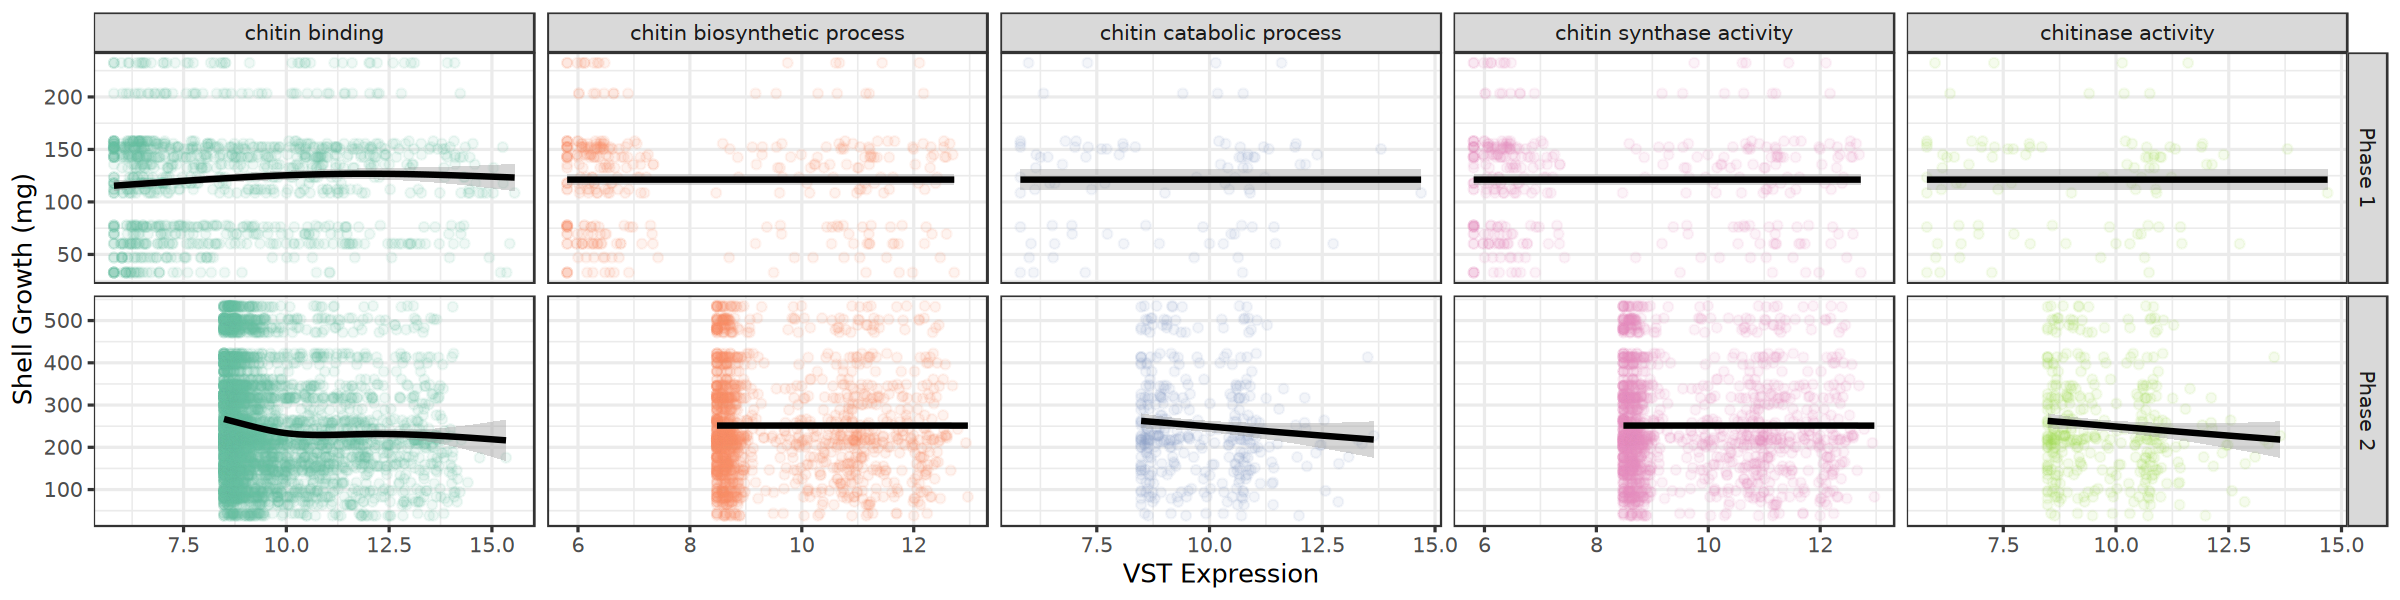

In [92]:
options(repr.plot.height = 5, repr.plot.width = 20)

ggplot(vst.chitin, aes(x = vst, y = Actual_shell_growth_mg, color = name)) +
geom_point(alpha = 0.1) +
geom_smooth(color = 'black') +
scale_color_brewer(palette = 'Set2') +
facet_grid(phase~name, scales = 'free') +
guides(color = 'none') +
theme_bw(base_size = 15) +
labs(x = 'VST Expression',
     y = 'Shell Growth (mg)')

hm okay so before when i was seeing a linear relationship, it was because i wasn't accounting for oysters from different phases - now we don't really see any relationships but we're also looking at over 100 genes

#### tissue vs. chitin expr (all)

`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'


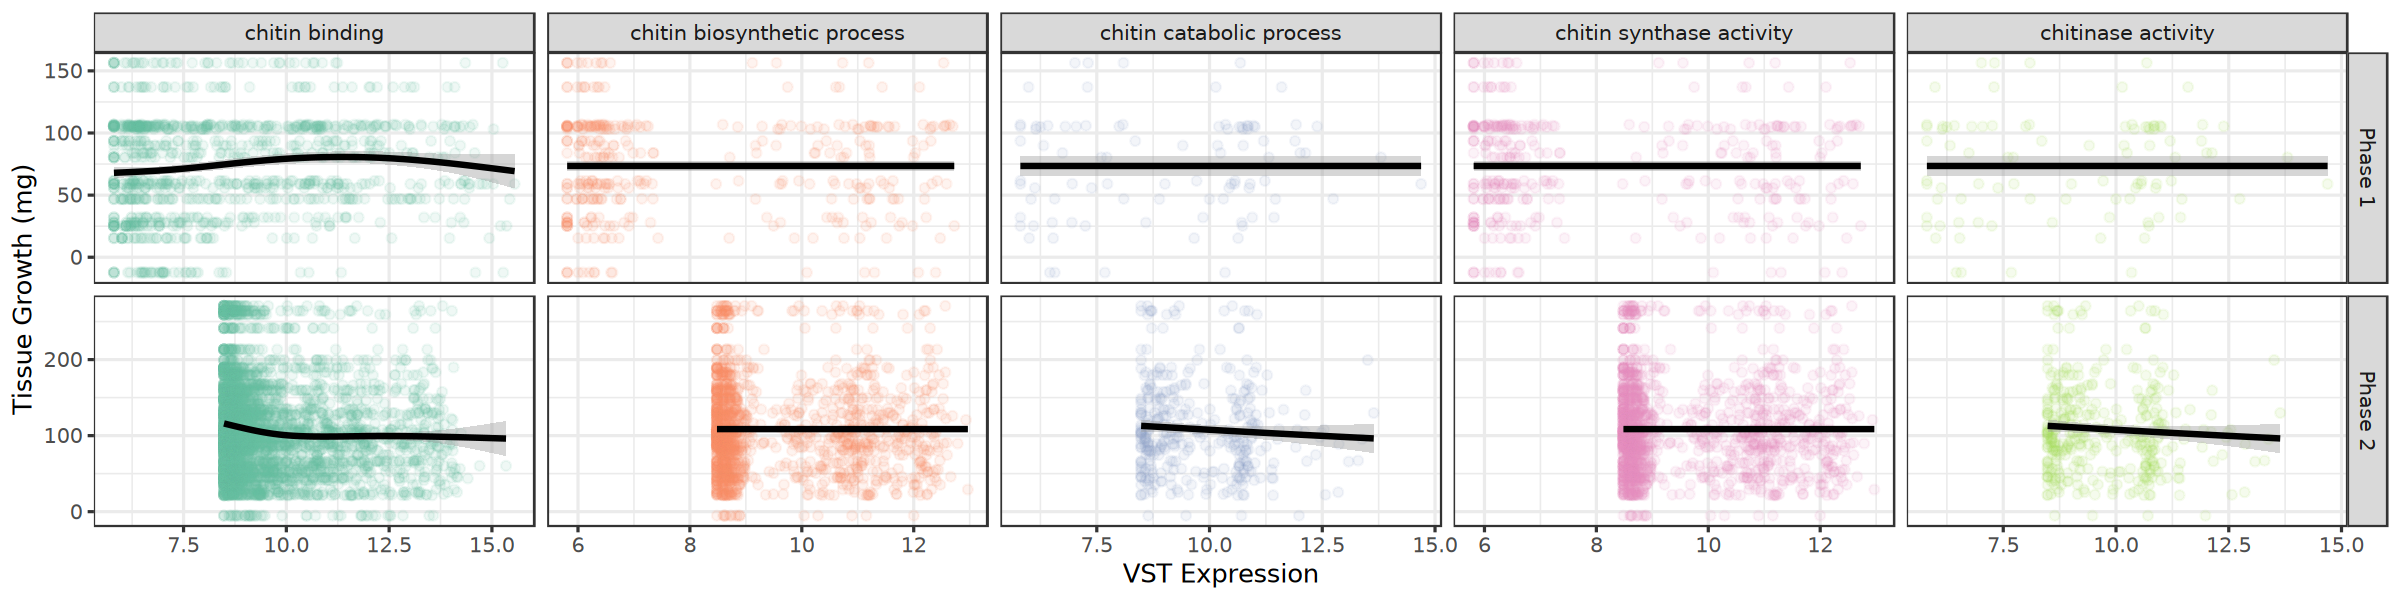

In [93]:
options(repr.plot.height = 5, repr.plot.width = 20)

ggplot(vst.chitin, aes(x = vst, y = Actual_tissue_growth_mg, color = name)) +
geom_point(alpha = 0.1) +
geom_smooth(color = 'black') +
scale_color_brewer(palette = 'Set2') +
facet_grid(phase~name, scales = 'free') +
guides(color = 'none') +
theme_bw(base_size = 15) +
labs(x = 'VST Expression',
     y = 'Tissue Growth (mg)')

#### treatment-specific vst expression

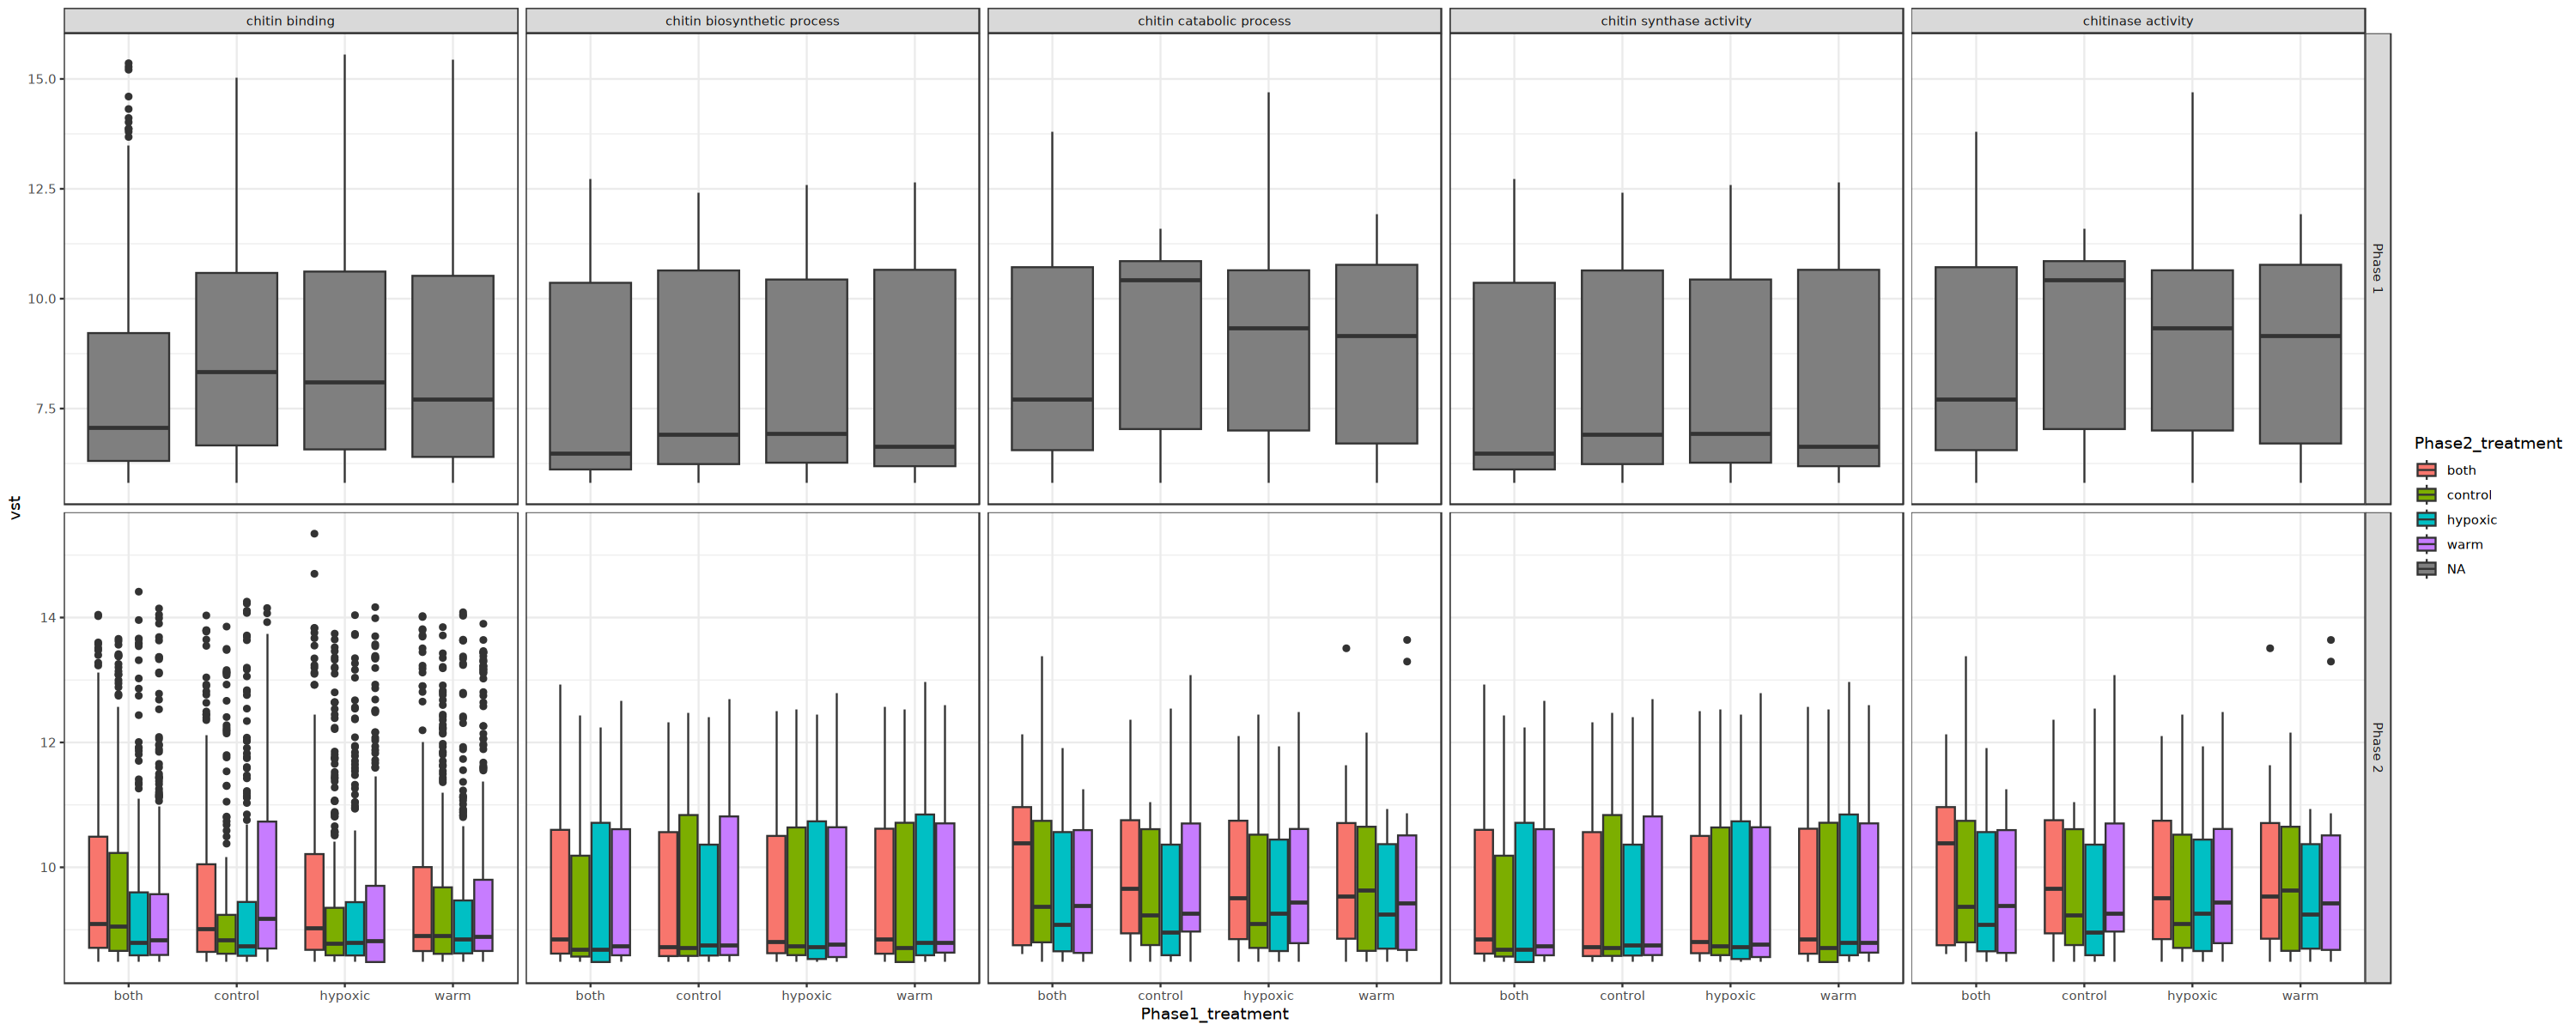

In [101]:
options(repr.plot.width = 25, repr.plot.height = 10)

ggplot(vst.chitin, aes(x = Phase1_treatment, y = vst, fill = Phase2_treatment)) +
geom_boxplot() +
facet_grid(phase~name, scales = 'free') +
theme_bw()

chitin binding, chitin catabolic process, and chitinase activity look like interesting GO categories to focus in on - since there seems to be variation among treatments and some outliers.

as a reminder:

In [104]:
chitin_genes %>%
count(name)

name,n
<chr>,<int>
chitin binding,62
chitin biosynthetic process,18
chitin catabolic process,4
chitin synthase activity,18
chitinase activity,4


so this makes sense that there is a lot of variation in the chitin binding category, there's 62 genes associated with that GO term! the other two categories may be a bit easier to manage since they only have 4 genes associated with them 

#### chitin catabolic process

In [131]:
vst.ccp <- vst.chitin %>% filter(name == 'chitin catabolic process') 

`geom_smooth()` using method = 'loess' and formula = 'y ~ x'


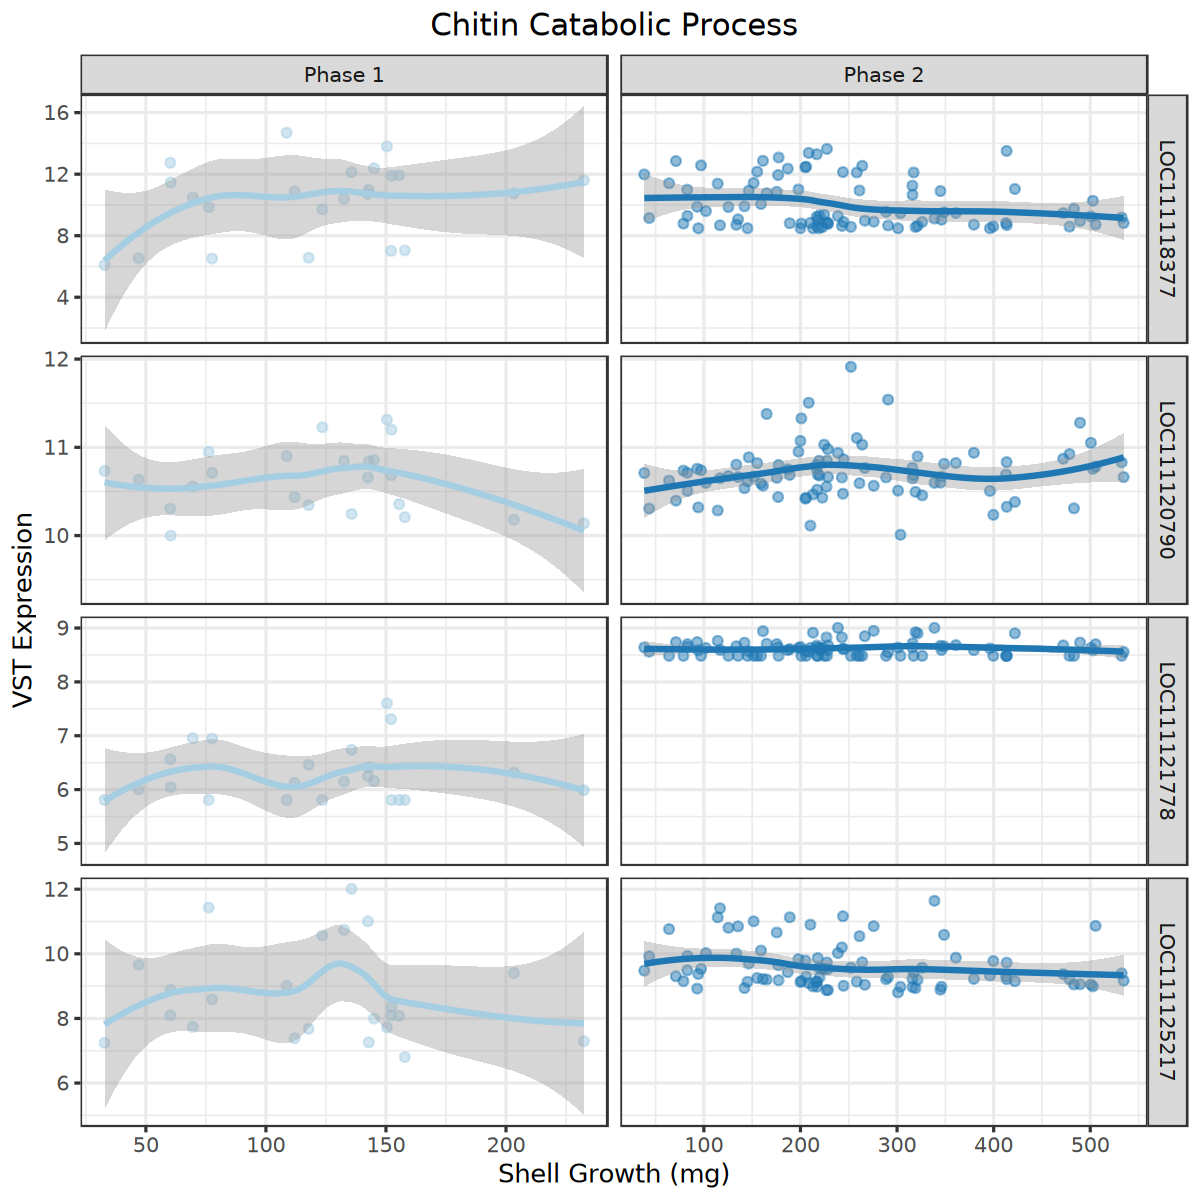

In [129]:
options(repr.plot.height = 10, repr.plot.width = 10)

ggplot(vst.ccp, aes(y = vst, x = Actual_shell_growth_mg, color = phase)) +
geom_point(alpha = 0.5) +
geom_smooth() +
scale_color_brewer(palette = 'Paired') +
facet_grid(Gene~phase, scales = 'free') +
theme_bw(base_size = 15) +
labs(y = 'VST Expression',
     x = 'Shell Growth (mg)',
    title = 'Chitin Catabolic Process') +
theme(plot.title = element_text(hjust = 0.5)) +
guides(color = 'none')

`geom_smooth()` using method = 'loess' and formula = 'y ~ x'


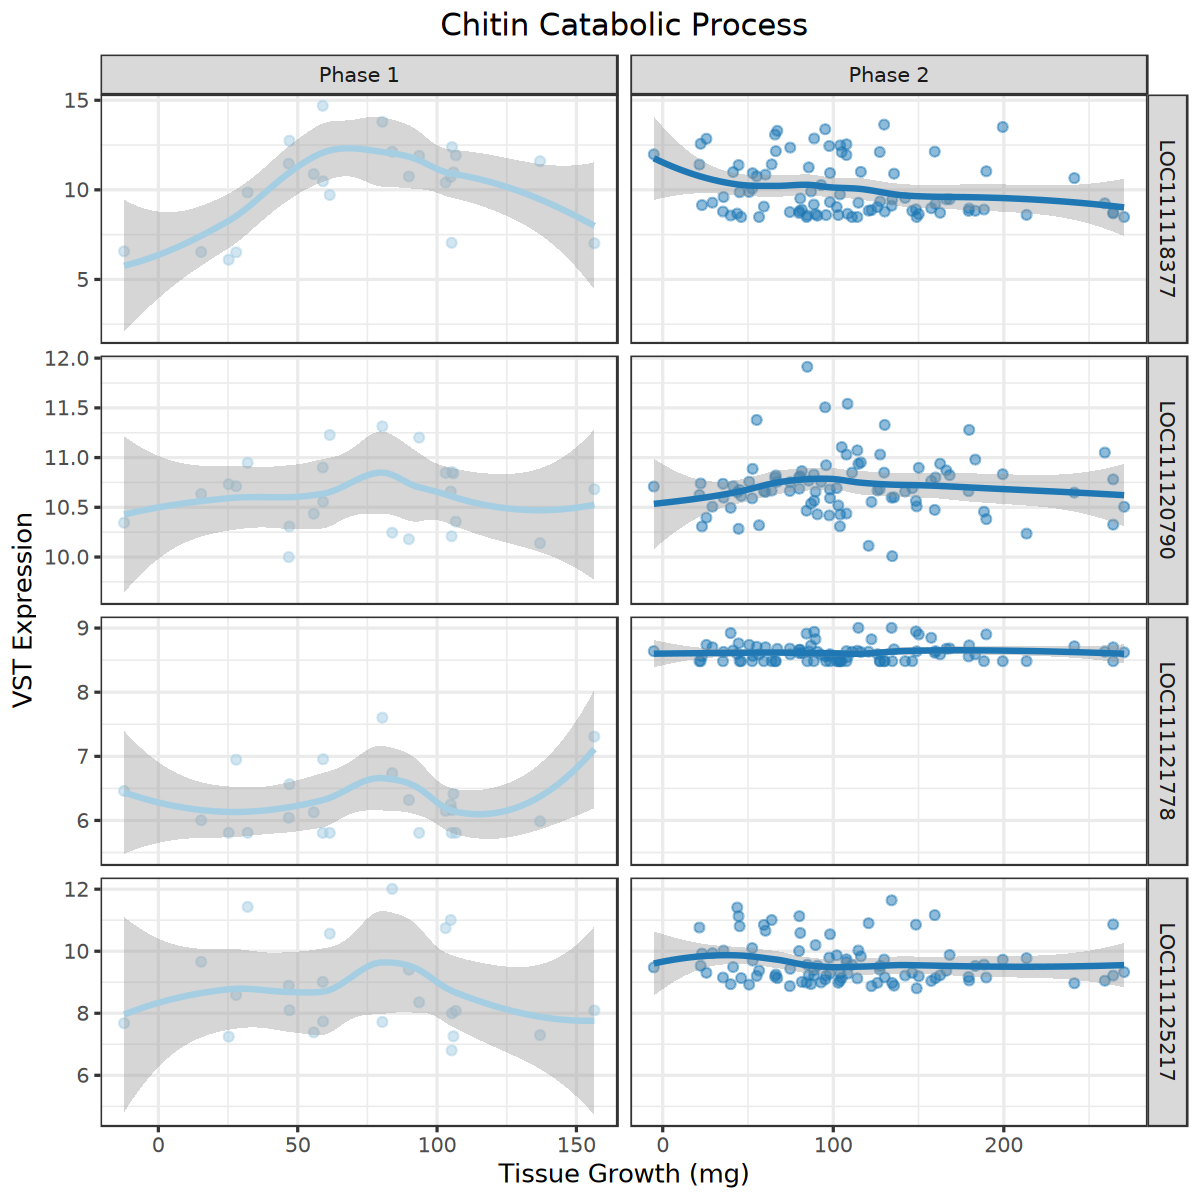

In [130]:
options(repr.plot.height = 10, repr.plot.width = 10)

ggplot(vst.ccp, aes(y = vst, x = Actual_tissue_growth_mg, color = phase)) +
geom_point(alpha = 0.5) +
geom_smooth() +
scale_color_brewer(palette = 'Paired') +
facet_grid(Gene~phase, scales = 'free') +
theme_bw(base_size = 15) +
labs(y = 'VST Expression',
     x = 'Tissue Growth (mg)',
    title = 'Chitin Catabolic Process') +
theme(plot.title = element_text(hjust = 0.5)) +
guides(color = 'none')

#### chitinase activity

In [136]:
vst.ca <- vst.chitin %>% filter(name == 'chitinase activity') 

`geom_smooth()` using method = 'loess' and formula = 'y ~ x'


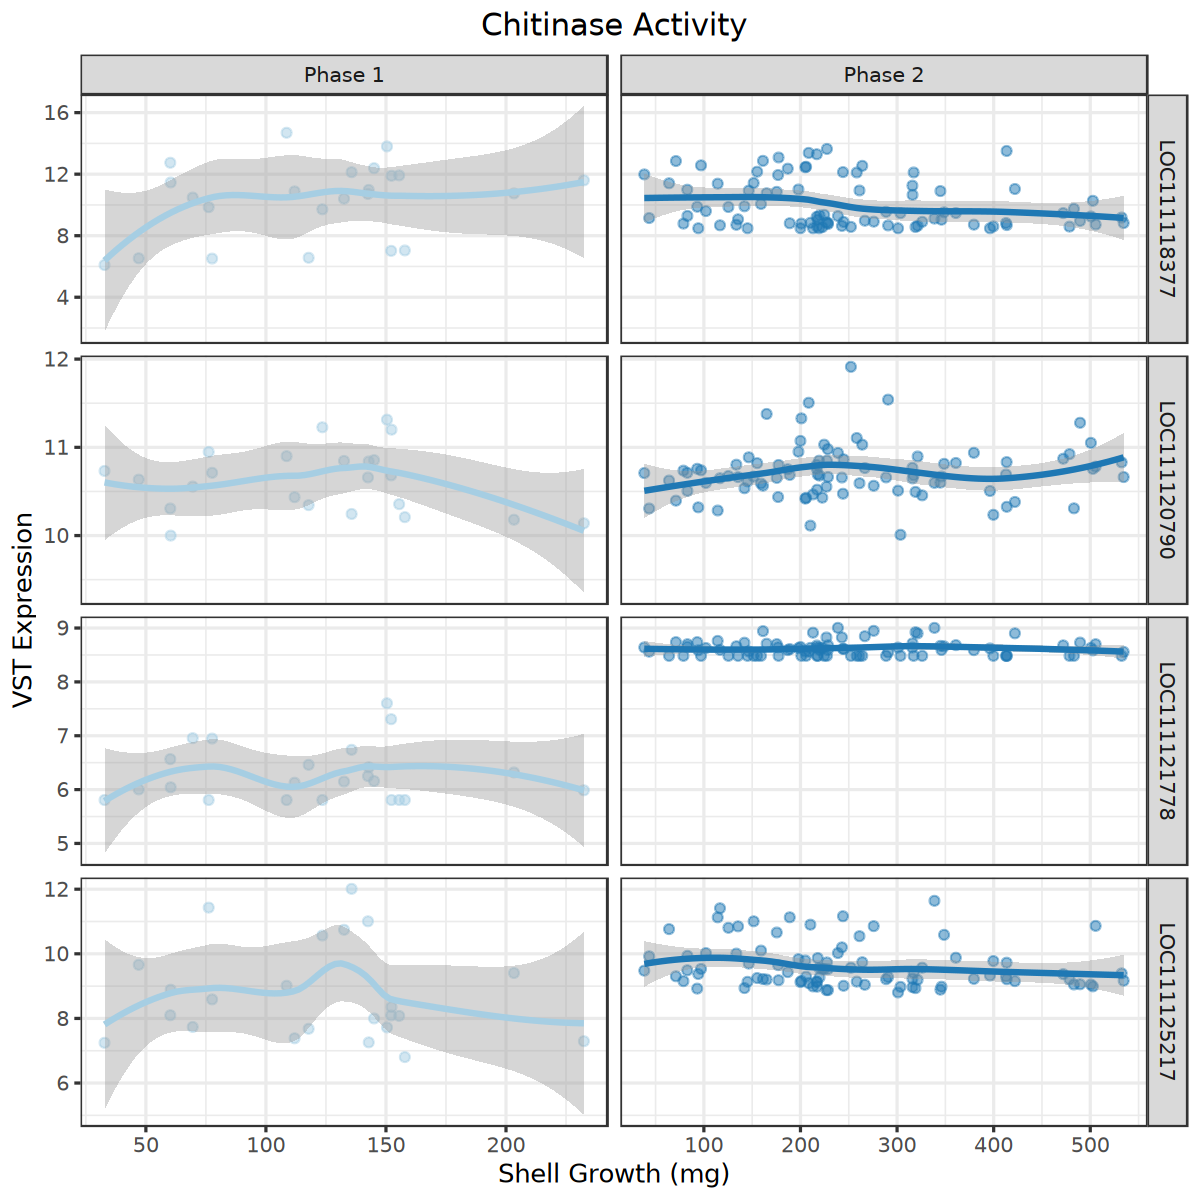

In [137]:
options(repr.plot.height = 10, repr.plot.width = 10)

ggplot(vst.ca, aes(y = vst, x = Actual_shell_growth_mg, color = phase)) +
geom_point(alpha = 0.5) +
geom_smooth() +
scale_color_brewer(palette = 'Paired') +
facet_grid(Gene~phase, scales = 'free') +
theme_bw(base_size = 15) +
labs(y = 'VST Expression',
     x = 'Shell Growth (mg)',
    title = 'Chitinase Activity') +
theme(plot.title = element_text(hjust = 0.5)) +
guides(color = 'none')

`geom_smooth()` using method = 'loess' and formula = 'y ~ x'


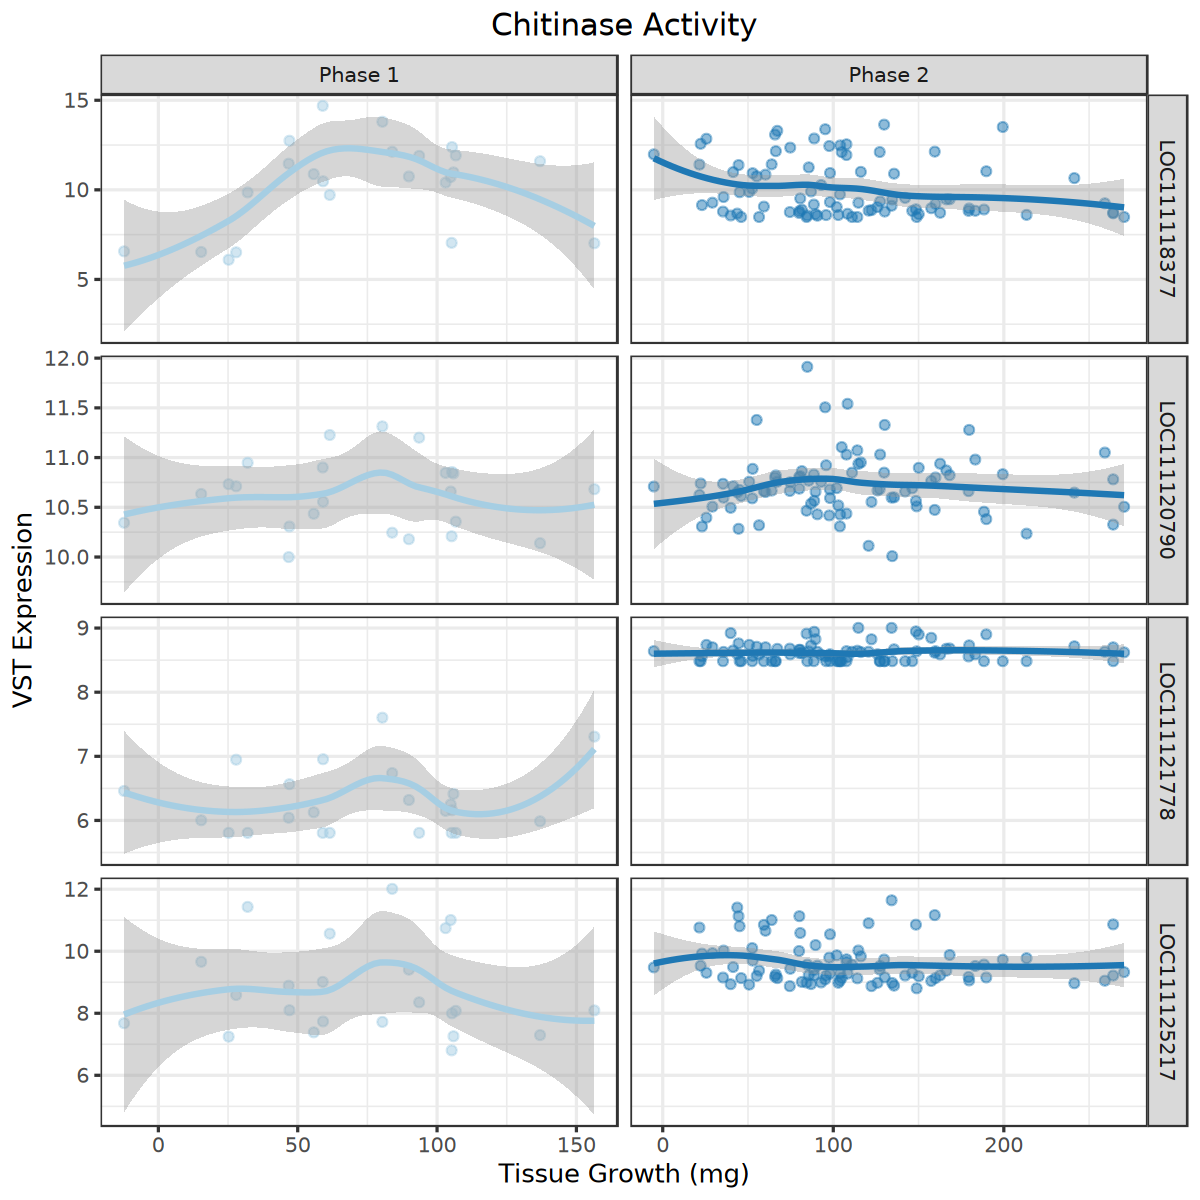

In [138]:
options(repr.plot.height = 10, repr.plot.width = 10)

ggplot(vst.ca, aes(y = vst, x = Actual_tissue_growth_mg, color = phase)) +
geom_point(alpha = 0.5) +
geom_smooth() +
scale_color_brewer(palette = 'Paired') +
facet_grid(Gene~phase, scales = 'free') +
theme_bw(base_size = 15) +
labs(y = 'VST Expression',
     x = 'Tissue Growth (mg)',
    title = 'Chitinase Activity') +
theme(plot.title = element_text(hjust = 0.5)) +
guides(color = 'none')

#### LOC111125340/LOC111125343/LOC111125342
pulled from [phase 1 GO analysis](https://github.com/jgmcdonough/CE24_RNA-seq/blob/main/analysis/diff_expression/phase1_v_phase1/new_refGenome/GO_newRef_p1.v.p1.ipynb) when I saw enrichment for chitin related processes.

These genes specifically were listed for the GO term chitin biosynthetic process

In [143]:
vst.go <- vst.chitin %>% filter(Gene %in% c('LOC111125340', 'LOC111125343', 'LOC111125342'))
head(vst.go)

,Gene,Sample,vst,Phase1_temp,Phase1_DO,Phase1_treatment,Phase2_temp,Phase2_DO,Phase2_treatment,complete_trtmt,Actual_shell_growth_mg,Actual_tissue_growth_mg,Ratio_tissue_shell_mg,phase,term,name
,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>
1,LOC111125340,B3_H4_O41,8.483578,warm,hypoxic,both,ambient,hypoxic,hypoxic,both_hypoxic,142.0310,86.96902,0.612324297,Phase 2,GO:0006031,chitin biosynthetic process
2,LOC111125340,B3_H4_O41,8.483578,warm,hypoxic,both,ambient,hypoxic,hypoxic,both_hypoxic,142.0310,86.96902,0.612324297,Phase 2,GO:0004100,chitin synthase activity
3,LOC111125340,W3_H2_G18,8.614914,warm,normoxic,warm,ambient,hypoxic,hypoxic,warm_hypoxic,532.4974,88.60258,0.166390628,Phase 2,GO:0006031,chitin biosynthetic process
4,LOC111125340,W3_H2_G18,8.614914,warm,normoxic,warm,ambient,hypoxic,hypoxic,warm_hypoxic,532.4974,88.60258,0.166390628,Phase 2,GO:0004100,chitin synthase activity
5,LOC111125340,W5_C4_G45,8.723360,warm,normoxic,warm,ambient,normoxic,control,warm_control,399.6502,213.34984,0.533841498,Phase 2,GO:0006031,chitin biosynthetic process
6,LOC111125340,W5_C4_G45,8.723360,warm,normoxic,warm,ambient,normoxic,control,warm_control,399.6502,213.34984,0.533841498,Phase 2,GO:0004100,chitin synthase activity


`geom_smooth()` using method = 'loess' and formula = 'y ~ x'


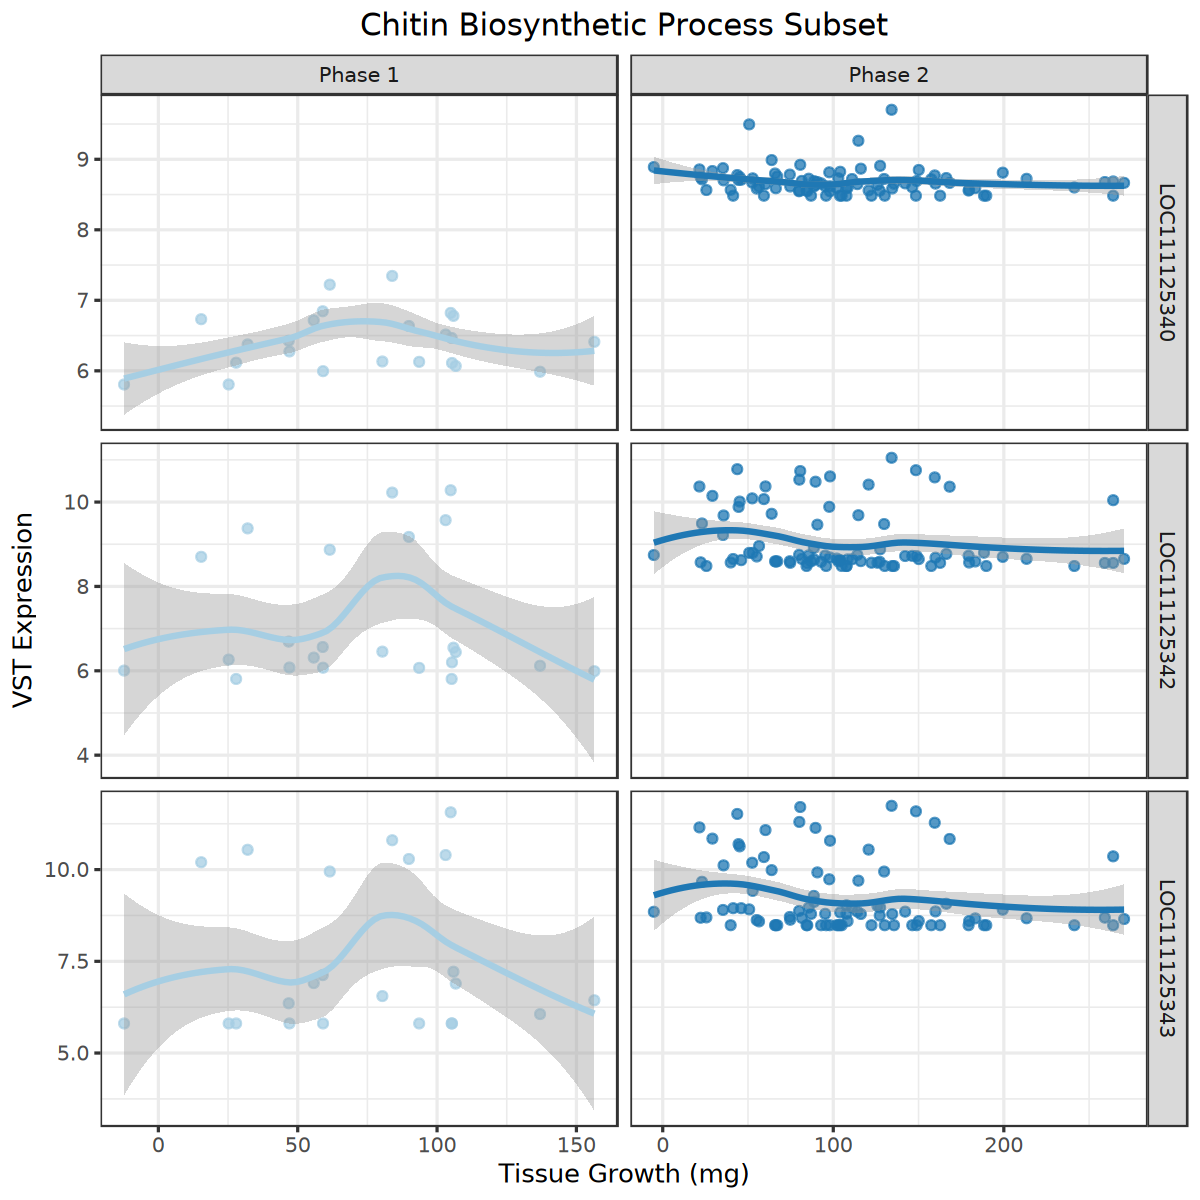

In [145]:
ggplot(vst.go, aes(y = vst, x = Actual_tissue_growth_mg, color = phase)) +
geom_point(alpha = 0.5) +
geom_smooth() +
scale_color_brewer(palette = 'Paired') +
facet_grid(Gene~phase, scales = 'free') +
theme_bw(base_size = 15) +
labs(y = 'VST Expression',
     x = 'Tissue Growth (mg)',
    title = 'Chitin Biosynthetic Process Subset') +
theme(plot.title = element_text(hjust = 0.5)) +
guides(color = 'none')

`geom_smooth()` using method = 'loess' and formula = 'y ~ x'


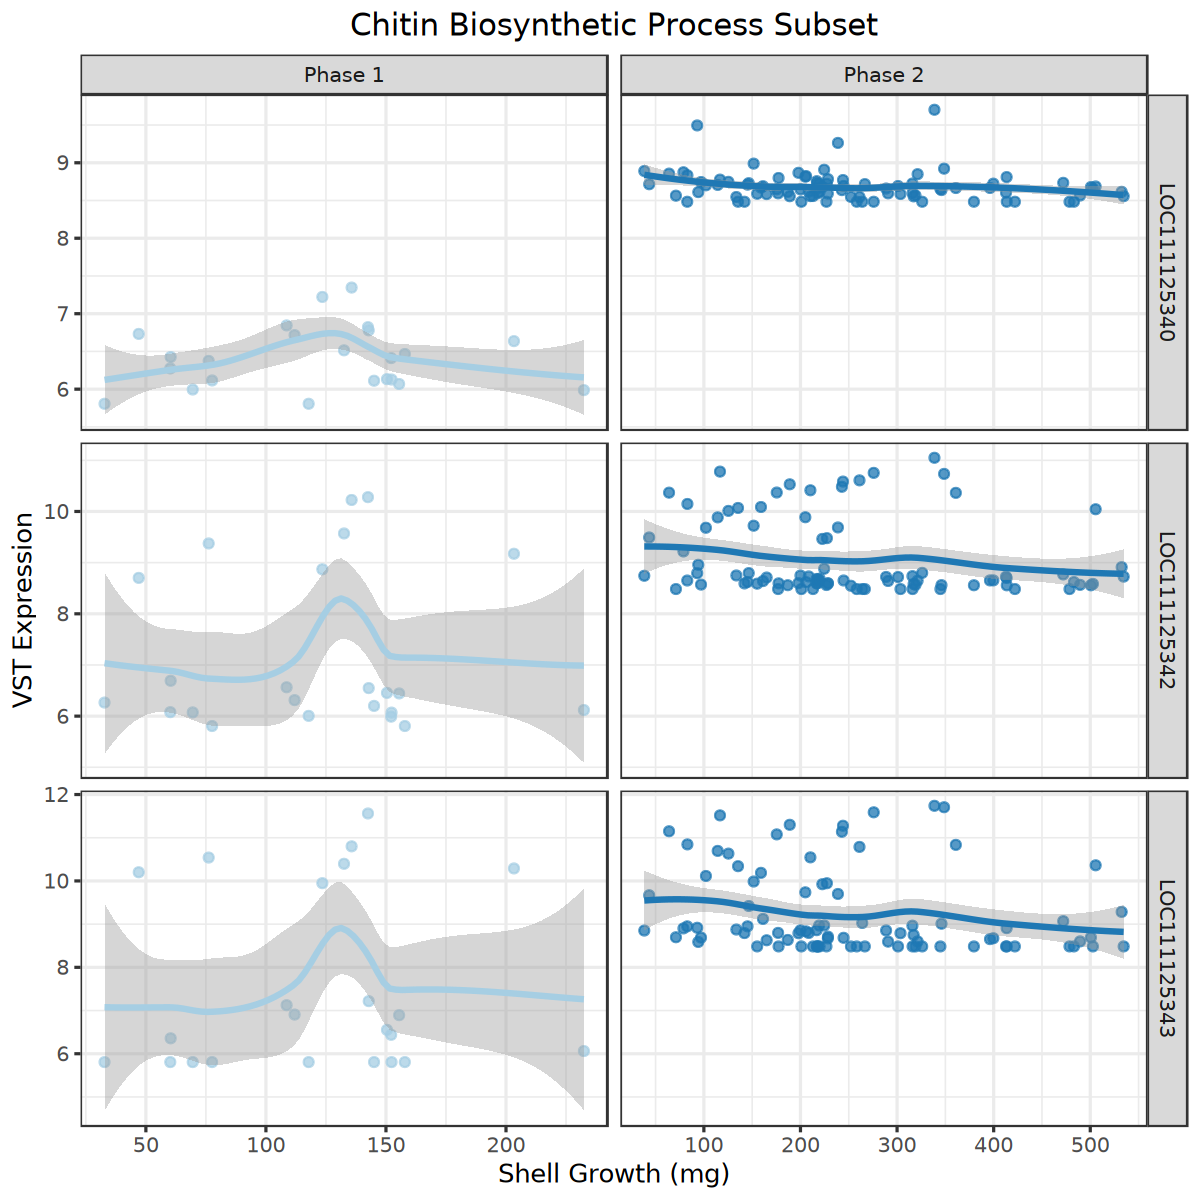

In [146]:
ggplot(vst.go, aes(y = vst, x = Actual_shell_growth_mg, color = phase)) +
geom_point(alpha = 0.5) +
geom_smooth() +
scale_color_brewer(palette = 'Paired') +
facet_grid(Gene~phase, scales = 'free') +
theme_bw(base_size = 15) +
labs(y = 'VST Expression',
     x = 'Shell Growth (mg)',
    title = 'Chitin Biosynthetic Process Subset') +
theme(plot.title = element_text(hjust = 0.5)) +
guides(color = 'none')

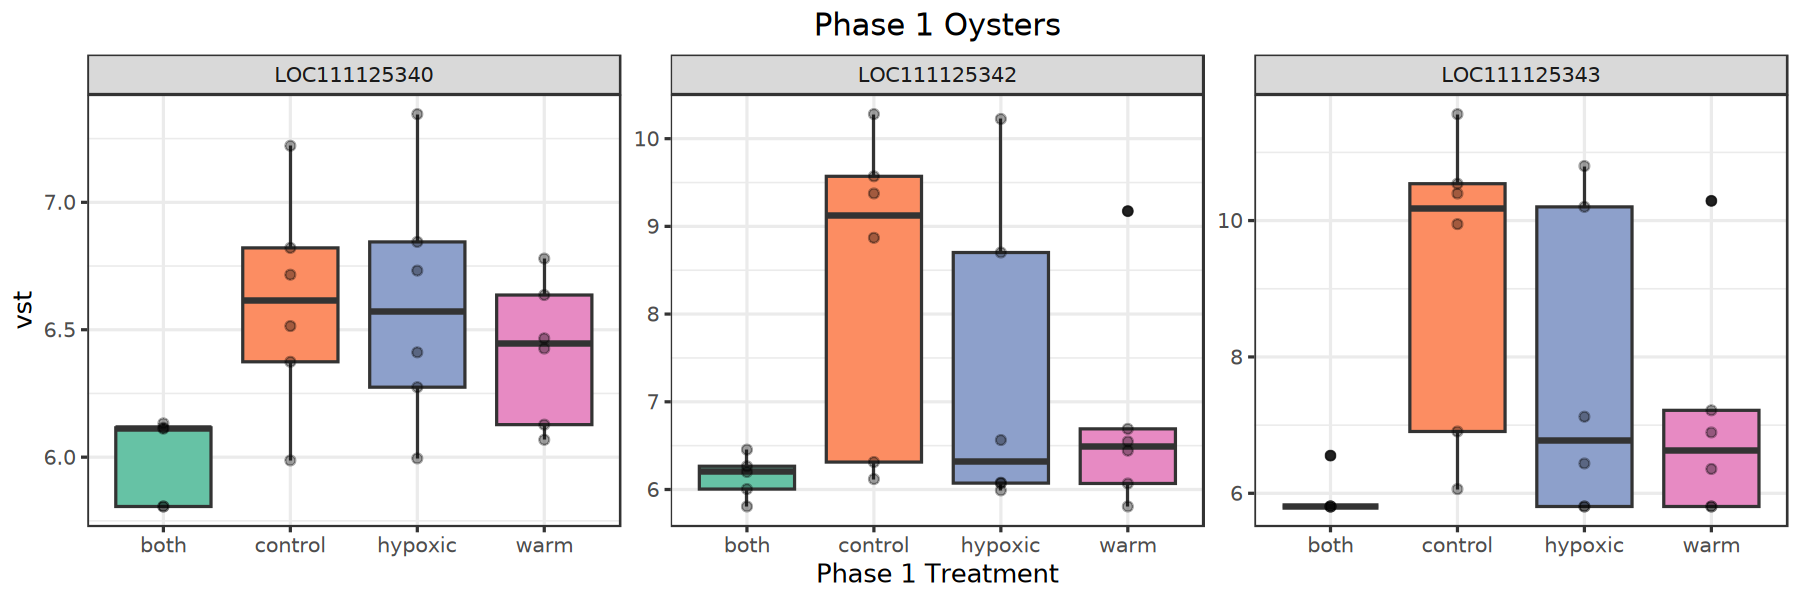

In [164]:
options(repr.plot.height = 5, repr.plot.width = 15)

ggplot(vst.go %>% filter(phase == 'Phase 1'), aes(x = Phase1_treatment, y = vst, fill = Phase1_treatment)) +
geom_boxplot() +
geom_point(alpha = 0.2) +
scale_fill_brewer(palette = 'Set2') +
facet_wrap( ~ Gene, scales = 'free_y') +
theme_bw(base_size = 15) +
labs(x = 'Phase 1 Treatment',
     title = 'Phase 1 Oysters') +
theme(plot.title = element_text(hjust = 0.5)) +
guides(fill = 'none')

for phase 1 oysters, the both treatment has decreased expression of these genes. Warm also has decreased expression, but not to the degree that both does.

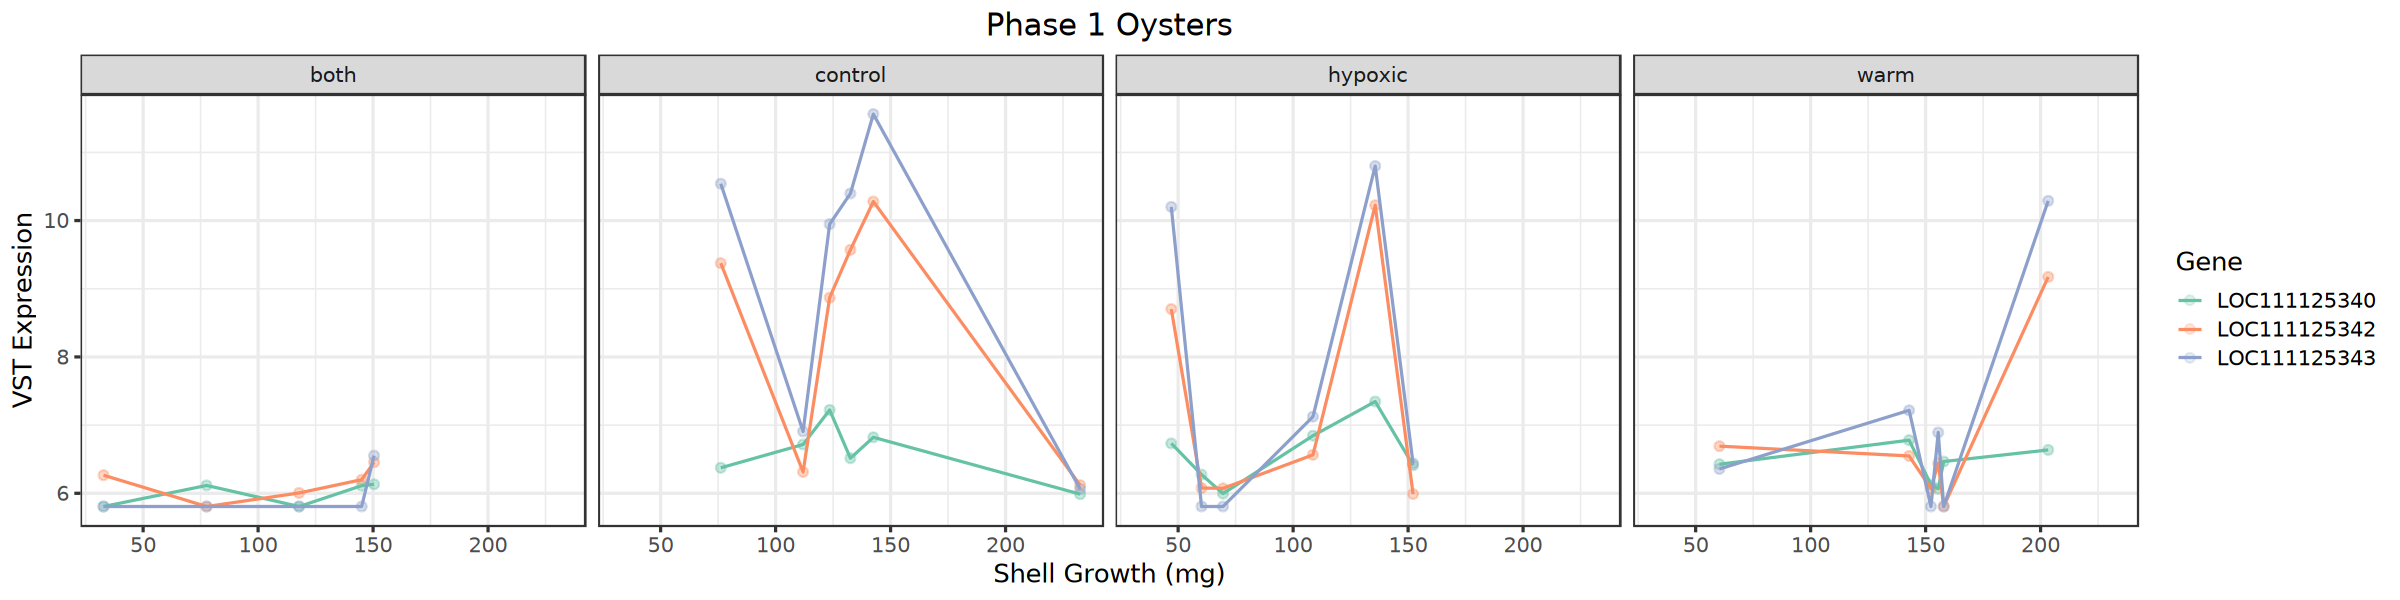

In [177]:
options(repr.plot.height = 5, repr.plot.width = 20)

ggplot(vst.go %>% filter(phase == 'Phase 1'), aes(x = Actual_shell_growth_mg, y = vst, color = Gene)) +
geom_point(alpha = 0.2) +
geom_line()  +
scale_color_brewer(palette = 'Set2') +
facet_wrap( ~ Phase1_treatment,  nrow = 1) +
theme_bw(base_size = 15) +
labs(x = 'Shell Growth (mg)',
     y = 'VST Expression',
     title = 'Phase 1 Oysters') +
theme(plot.title = element_text(hjust = 0.5)) +
guides(fill = 'none')

seems like LOC11115342 and LOC111125343 are co-expressed? show similar patterns, with the same peaks and valleys

but they peak in expression at different shell growths depending on the treatment (control ~ 140mg, hypoxic ~ 140mg, warm ~ 200mg (and valley at 140mg), while both "peaks" at 150mg)